In [ ]:
"""
Complete self-contained implementation of Gillespie-based discrete diffusion experiment.
Compares forward and reverse processes using Hellinger distance.
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import logsumexp


# ============================================================================
# Data Sampling Functions
# ============================================================================
def sample_from_pi(w, mu, rng=None):
    """
    Sample x from the true mixture q(x) = sum_i w_i ∏_j mu[i,j,x_j].
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component-wise categorical probabilities
    rng : np.random.Generator, optional
        Random number generator
    
    Returns
    -------
    x : np.ndarray, shape (N,)
        Sample from the mixture
    """
    if rng is None:
        rng = np.random.default_rng()
    w = np.asarray(w)
    mu = np.asarray(mu)
    r, N, L = mu.shape
    
    # Pick mixture component
    i = rng.choice(r, p=w)
    
    # Sample each coordinate independently from that component
    x = np.empty(N, dtype=int)
    for j in range(N):
        x[j] = rng.choice(L, p=mu[i, j])
    
    return x


def make_conditional_prob_fn_mixture(w, mu, MASK=-1, eps=1e-300):
    """
    Build conditional probability function for the mixture-of-independent-coordinates model.
    
    Data model:
        p_data(x) = sum_r w[r] * prod_j mu[r, j, x_j]
    
    For a partially masked vector z, this returns
        probs[j, v] = p_data(X_j = v | X_i = z_i for all visible i)
    where visible means z[i] != MASK.
    
    Parameters
    ----------
    w : np.ndarray, shape (R,)
        Mixture weights
    mu : np.ndarray, shape (R, N, L)
        Component-wise categorical probabilities
        mu[r, j, v] = p(X_j = v | component r)
    MASK : int
        Mask token
    eps : float
        Numerical stability constant
    
    Returns
    -------
    cond_prob_fn : callable
        cond_prob_fn(z) returns an array of shape (N, L)
    """
    w = np.asarray(w, dtype=float)
    mu = np.asarray(mu, dtype=float)
    
    if w.ndim != 1:
        raise ValueError("w must have shape (R,)")
    if mu.ndim != 3:
        raise ValueError("mu must have shape (R, N, L)")
    
    R, N, L = mu.shape
    if w.shape[0] != R:
        raise ValueError("w and mu have inconsistent number of mixture components")
    
    # Normalize mixture weights
    w = np.clip(w, 0.0, None)
    w_sum = w.sum()
    if w_sum <= 0:
        raise ValueError("mixture weights must have positive sum")
    w = w / w_sum
    
    # Normalize mu
    mu = np.clip(mu, 0.0, None)
    mu_sum = mu.sum(axis=-1, keepdims=True)
    mu = np.divide(mu, mu_sum, out=np.ones_like(mu) / L, where=(mu_sum > 0))
    
    log_w = np.log(np.clip(w, eps, None))
    log_mu = np.log(np.clip(mu, eps, None))
    
    def logsumexp_stable(a):
        a = np.asarray(a, dtype=float)
        a_max = np.max(a)
        if not np.isfinite(a_max):
            return -np.inf
        return a_max + np.log(np.sum(np.exp(a - a_max)))
    
    def cond_prob_fn(z):
        z = np.asarray(z, dtype=int)
        if z.shape != (N,):
            raise ValueError(f"z must have shape ({N},), got {z.shape}")
        
        visible_idx = np.where(z != MASK)[0]
        
        # Log posterior over mixture components:
        # log p(r | visible z) ∝ log w_r + sum_{i visible} log mu[r, i, z_i]
        log_comp = log_w.copy()
        for i in visible_idx:
            v = int(z[i])
            if v < 0 or v >= L:
                raise ValueError(f"visible token z[{i}]={v} is outside [0, {L-1}]")
            log_comp += log_mu[:, i, v]
        
        log_Z = logsumexp_stable(log_comp)
        if not np.isfinite(log_Z):
            comp_post = np.ones(R, dtype=float) / R
        else:
            comp_post = np.exp(log_comp - log_Z)
            comp_post = comp_post / comp_post.sum()
        
        # Predictive distribution:
        # p(X_j = v | visible z) = sum_r p(r | visible z) mu[r, j, v]
        probs = np.einsum("r,rjl->jl", comp_post, mu)
        
        # Normalize rows
        probs = np.clip(probs, 0.0, None)
        row_sums = probs.sum(axis=1, keepdims=True)
        probs = np.divide(probs, row_sums, out=np.ones_like(probs) / L, where=(row_sums > 0))
        
        return probs
    
    return cond_prob_fn


# ============================================================================
# Forward Process Simulation
# ============================================================================
def generate_forward_samples_at_checkpoints(w, mu, beta, checkpoint_times, n_mc, MASK=-1):
    """
    Generate forward samples at checkpoint times using marginal distributions.
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Mixture weights
    mu : np.ndarray, shape (r, N, L)
        Component probabilities
    beta : float
        Masking rate
    checkpoint_times : array-like
        Physical times in [0, T] at which to sample
    n_mc : int
        Number of samples
    MASK : int
        Mask token
    
    Returns
    -------
    forward_samples : dict[float, np.ndarray]
        forward_samples[t] = array of shape (n_mc, N) at time t
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    forward_samples = {}
    rng = np.random.default_rng()
    
    for m in range(n_mc):
        # if m % 100 == 0:
        #     print(f"  Forward particle {m}/{n_mc}")
        
        # Sample clean data at t=0
        x0 = sample_from_pi(w, mu, rng=np.random.default_rng(rng.integers(1_000_000_000)))
        
        # Generate samples at each checkpoint time
        for t in checkpoint_times:
            if m == 0:
                forward_samples[float(t)] = np.empty((n_mc, N), dtype=int)
            
            if t == 0.0:
                # At t=0, use clean data
                forward_samples[float(t)][m] = x0
            else:
                # At t>0, apply forward marginal from t=0
                x_t = forward_marginal(
                    x0, beta, t, 
                    rng=np.random.default_rng(rng.integers(1_000_000_000))
                )
                forward_samples[float(t)][m] = x_t
    
    return forward_samples


def forward_marginal(x_t, beta, delta_t, rng=None, MASK=-1):
    """
    Corrupt x_t to time t + delta_t using the forward masking process.
    Each UNMASKED coordinate j is masked independently with probability 1 - e^{-beta*(delta_t)}.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    alpha_dt = np.exp(-beta * delta_t)
    x_t_delta_t = x_t.copy()
    
    # Only mask currently UNMASKED tokens
    unmasked_mask = (x_t != MASK)
    new_mask = rng.random(len(x_t)) < (1 - alpha_dt)
    
    # Apply masking only to unmasked positions
    x_t_delta_t[unmasked_mask & new_mask] = MASK
    
    return x_t_delta_t



# ============================================================================
# Reverse Process Simulation (Gillespie)
# ============================================================================

# def 
# pie_reverse_masked(
#     N, w, mu, beta, T=1.0, MASK=-1, rng=None,
#     checkpoint_times=None, unmasking_prob_fn=None
# ):
#     """
#     Exact Gillespie reverse sampler for constant-rate masked diffusion.
    
#     State starts fully masked at t=T and moves backward to t=0.
#     Each event unmasks exactly one currently masked coordinate.
    
#     Parameters
#     ----------
#     N : int
#         Number of dimensions
#     w : np.ndarray, shape (r,)
#         Mixture weights
#     mu : np.ndarray, shape (r, N, L)
#         Component probabilities
#     beta : float
#         Forward masking rate
#     T : float
#         Terminal time
#     MASK : int
#         Mask token value
#     rng : np.random.Generator, optional
#         Random number generator
#     checkpoint_times : array-like, optional
#         Times at which to save state (physical time in [0, T])
#     unmasking_prob_fn : callable, optional
#         Function to compute unmasking probabilities
    
#     Returns
#     -------
#     final_state : np.ndarray, shape (N,)
#         Final state at t=0
#     checkpoint_states : dict[float, np.ndarray]
#         checkpoint_states[t] = state at physical time t
#     """
#     if rng is None:
#         rng = np.random.default_rng()
#     if unmasking_prob_fn is None:
#         unmasking_prob_fn = make_conditional_prob_fn_mixture(w, mu, MASK=MASK)
    
#     # Normalize checkpoint times
#     checkpoint_times = np.sort(np.unique(np.asarray(checkpoint_times, dtype=float)))
    
#     # Storage: map physical time -> state
#     checkpoint_states = {}
    
#     # Start at t=T (fully masked)
#     x = np.full(N, MASK, dtype=int)
#     t = float(T)
    
#     # Record initial state at all checkpoints >= T
#     for ckpt_t in checkpoint_times:
#         if ckpt_t >= t:
#             checkpoint_states[float(ckpt_t)] = x.copy()
    
#     # Simulate backward from T to 0
#     while t > 0 and np.any(x == MASK):
#         masked_idx = np.where(x == MASK)[0]
#         M = len(masked_idx)
        
#         # Compute next jump time using the reverse rate
#         # Rate per masked token: beta * alpha_t / (1 - alpha_t)
#         alpha_t = np.exp(-beta * t)
#         E = rng.exponential(1.0)
        
#         # Solve: M * integral_s^t c(u) du = E
#         one_minus_alpha_s = (1.0 - alpha_t) * np.exp(-E / M)
        
#         if one_minus_alpha_s >= 1.0:
#             s = 0.0
#         else:
#             alpha_s = 1.0 - one_minus_alpha_s
#             alpha_s = np.clip(alpha_s, 0.0, 1.0)
#             if alpha_s >= 1.0:
#                 s = 0.0
#             else:
#                 s = -np.log(alpha_s) / beta
#                 s = max(s, 0.0)
        
#         # Move to time s
#         t = s
        
#         # Make jump at time s: unmask one token
#         d = rng.choice(masked_idx)
#         probs = unmasking_prob_fn(x)[d].astype(float)
#         probs = np.clip(probs, 0.0, None)
#         probs = probs / probs.sum()
#         x[d] = rng.choice(len(probs), p=probs)
        
#         # Record state at all checkpoints we just passed
#         for ckpt_t in checkpoint_times:
#             if ckpt_t <= t and ckpt_t not in checkpoint_states:
#                 checkpoint_states[float(ckpt_t)] = x.copy()
    
#     # Fill any remaining checkpoints with final state
#     for ckpt_t in checkpoint_times:
#         if ckpt_t not in checkpoint_states:
#             checkpoint_states[float(ckpt_t)] = x.copy()
    
#     return x, checkpoint_states

def gillespie_reverse_masked(
    N, w, mu, beta, T=1.0, MASK=-1, rng=None,
    checkpoint_times=None, unmasking_prob_fn=None
):
    """
    Exact Gillespie reverse sampler for constant-rate masked diffusion.
    """
    if rng is None:
        rng = np.random.default_rng()
    if unmasking_prob_fn is None:
        unmasking_prob_fn = make_conditional_prob_fn_mixture(w, mu, MASK=MASK)
    
    # Normalize checkpoint times
    checkpoint_times = np.sort(np.unique(np.asarray(checkpoint_times, dtype=float)))
    
    # Storage: ARRAY not dict!
    checkpoint_samples = np.empty((len(checkpoint_times), N), dtype=int)
    
    # Initialize pointer (NEW - this was missing!)
    ckpt_ptr = len(checkpoint_times) - 1
    
    # Start at t=T (fully masked)
    x = np.full(N, MASK, dtype=int)
    t = float(T)
    
    # Record initial state at all checkpoints >= T
    while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] >= t:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Simulate backward from T to 0
    while t > 0 and np.any(x == MASK):
        masked_idx = np.where(x == MASK)[0]
        M = len(masked_idx)
        x_before_jump = x.copy()

        alpha_t = np.exp(-beta * t)
        E = rng.exponential(1.0)
        one_minus_alpha_s = (1.0 - alpha_t) * np.exp(-E / M)

        alpha_s = 1.0 - one_minus_alpha_s
        alpha_s = np.clip(alpha_s, 0.0, 1.0)

        if alpha_s >= 1.0:
            s = 0.0
        else:
            s = -np.log(alpha_s) / beta
            s = max(s, 0.0)

        # Record checkpoints BEFORE applying the jump
        while ckpt_ptr >= 0 and checkpoint_times[ckpt_ptr] > s:
            checkpoint_samples[ckpt_ptr] = x_before_jump.copy()
            ckpt_ptr -= 1

        # Now move to event time and apply jump
        t = s

        d = rng.choice(masked_idx)
        probs = unmasking_prob_fn(x)[d].astype(float)
        probs = np.clip(probs, 0.0, None)
        probs = probs / probs.sum()
        x[d] = rng.choice(len(probs), p=probs)
        

    
    # Fill any remaining checkpoints with final state
    while ckpt_ptr >= 0:
        checkpoint_samples[ckpt_ptr] = x.copy()
        ckpt_ptr -= 1
    
    # Return array, not dict!
    return x, checkpoint_times, checkpoint_samples
# ============================================================================
# Sample Container and Analysis
# ============================================================================

class DiffusionSamples:
    """
    Container for forward and reverse diffusion samples.
    
    Attributes
    ----------
    times : np.ndarray
        Sorted array of checkpoint times in [0, T]. Ascending order.
    forward : dict[float, np.ndarray]
        forward[t] = particles at time t from forward process
        Shape: (n_mc, N)
    reverse : dict[float, np.ndarray]
        reverse[t] = particles at time t from reverse process
        Shape: (n_mc, N)
    metadata : dict
        Additional information (n_mc, N, beta, T, etc.)
    """
    def __init__(self, times, n_mc, N):
        self.times = np.sort(times)  # Always ascending
        self.forward = {}
        self.reverse = {}
        self.metadata = {'n_mc': n_mc, 'N': N}
    
    def add_forward(self, t, particles):
        """Add forward samples at time t."""
        assert particles.shape == (self.metadata['n_mc'], self.metadata['N'])
        self.forward[float(t)] = particles.copy()
    
    def add_reverse(self, t, particles):
        """Add reverse samples at time t."""
        assert particles.shape == (self.metadata['n_mc'], self.metadata['N'])
        self.reverse[float(t)] = particles.copy()
    
    def get_comparison_pairs(self):
        """Get all (t, forward_particles, reverse_particles) for comparison."""
        pairs = []
        for t in self.times:
            t = float(t)
            if t in self.forward and t in self.reverse:
                pairs.append((t, self.forward[t], self.reverse[t]))
        return pairs
    
    def particles_to_pmf(self, particles):
        """
        Convert an array of particles into an empirical PMF over full states.
        
        Parameters
        ----------
        particles : np.ndarray, shape (n_mc, N)
            Each row is one particle / state.
        
        Returns
        -------
        pmf : dict
            Maps state tuples to probabilities.
        """
        particles = np.asarray(particles, dtype=int)
        counts = Counter(map(tuple, particles))
        n_mc = len(particles)
        return {state: count / n_mc for state, count in counts.items()}
    
    def hellinger_distance(self, p, q):
        """
        Hellinger distance between two PMFs represented as dicts.
        
        Parameters
        ----------
        p, q : dict
            PMFs mapping states to probabilities
        
        Returns
        -------
        distance : float
            Hellinger distance between p and q
        """
        support = set(p.keys()) | set(q.keys())
        s = 0.0
        for x in support:
            px = p.get(x, 0.0)
            qx = q.get(x, 0.0)
            s += (np.sqrt(px) - np.sqrt(qx)) ** 2
        return np.sqrt(0.5 * s)
    
    def compute_hellinger_distances(self):
        """Compute Hellinger distance at each checkpoint."""
        distances = {}
        for t, fwd_particles, rev_particles in self.get_comparison_pairs():
            fwd_pmf = self.particles_to_pmf(fwd_particles)
            rev_pmf = self.particles_to_pmf(rev_particles)
            distances[t] = self.hellinger_distance(fwd_pmf, rev_pmf)
        return distances


# ============================================================================
# Main Experiment Runner
# ============================================================================
# def run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times):
#     """
#     Run complete forward + reverse experiment using marginal sampling.
#     """
#     N = mu.shape[1]
#     checkpoint_times = np.sort(np.unique(checkpoint_times))
    
#     samples = DiffusionSamples(checkpoint_times, n_mc, N)
    
#     # 1) Forward simulation using marginals
#     print("Running forward process...")
#     samples.forward = generate_forward_samples_at_checkpoints(
#         w, mu, beta, checkpoint_times, n_mc
#     )
    
#     # 2) Reverse simulation  
#     print("\nRunning reverse process...")
#     rng = np.random.default_rng()
#     for m in range(n_mc):
#         if m % 100 == 0:
#             print(f"  Reverse particle {m}/{n_mc}")
        
#         _, trajectory = gillespie_reverse_masked(
#             N, w, mu, beta, T,
#             checkpoint_times=checkpoint_times,
#             rng=np.random.default_rng(rng.integers(1_000_000_000))
#         )
        
#         for t, state in trajectory.items():
#             if m == 0:
#                 samples.reverse[t] = np.empty((n_mc, N), dtype=int)
#             samples.reverse[t][m] = state
    
#     return samples

def run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times):
    """
    Run complete forward + reverse experiment using marginal sampling.
    """
    N = mu.shape[1]
    checkpoint_times = np.sort(np.unique(checkpoint_times))
    
    samples = DiffusionSamples(checkpoint_times, n_mc, N)
    
    # 1) Forward simulation using marginals
    print("Running forward process...")
    samples.forward = generate_forward_samples_at_checkpoints(
        w, mu, beta, checkpoint_times, n_mc
    )
    
    # DEBUGGING: Check forward samples
    print("\n=== FORWARD SAMPLES DEBUG ===")
    t0 = checkpoint_times[0]
    tT = checkpoint_times[-1]
    print(f"At t={t0}:")
    print(f"  Shape: {samples.forward[t0].shape}")
    print(f"  Fraction masked: {(samples.forward[t0] == -1).sum() / samples.forward[t0].size:.1%}")
    print(f"  First 3 samples:\n{samples.forward[t0][:3]}")
    
    print(f"\nAt t={tT}:")
    print(f"  Shape: {samples.forward[tT].shape}")
    print(f"  Fraction masked: {(samples.forward[tT] == -1).sum() / samples.forward[tT].size:.1%}")
    print(f"  First 3 samples:\n{samples.forward[tT][:3]}")
    
    # 2) Reverse simulation   
    print("\nRunning reverse process...")
    rng = np.random.default_rng()
    for m in range(n_mc):
        # if m % 100 == 0:
        #     print(f"  Reverse particle {m}/{n_mc}")
        
        final_state, times, ckpt_samples = gillespie_reverse_masked(
            N, w, mu, beta, T,
            checkpoint_times=checkpoint_times,
            rng=np.random.default_rng(rng.integers(1_000_000_000))
        )
        # print("DEBUGGING: Reverse trajectory times:")
        # print(times[:5])
        # print(times[-5:])
        # Store samples at each checkpoint
        for k, t in enumerate(times):
            if m == 0:
                samples.reverse[float(t)] = np.empty((n_mc, N), dtype=int)
            samples.reverse[float(t)][m] = ckpt_samples[k]
    # print("\n\nRunning reverse process...")
    # rng = np.random.default_rng()
    # for m in range(n_mc):
    #     if m % 100 == 0:
    #         print(f"  Reverse particle {m}/{n_mc}")
        
    #     _, trajectory = gillespie_reverse_masked(
    #         N, w, mu, beta, T,
    #         checkpoint_times=checkpoint_times,
    #         rng=np.random.default_rng(rng.integers(1_000_000_000))
    #     )
        
    #     for t, state in trajectory.items():
    #         if m == 0:
    #             samples.reverse[t] = np.empty((n_mc, N), dtype=int)
    #         samples.reverse[t][m] = state
    
    # DEBUGGING: Check reverse samples
    print("\n=== REVERSE SAMPLES DEBUG ===")
    print(f"At t={t0}:")
    print(f"  Shape: {samples.reverse[t0].shape}")
    print(f"  Fraction masked: {(samples.reverse[t0] == -1).sum() / samples.reverse[t0].size:.1%}")
    print(f"  First 3 samples:\n{samples.reverse[t0][:3]}")
    
    print(f"\nAt t={tT}:")
    print(f"  Shape: {samples.reverse[tT].shape}")
    print(f"  Fraction masked: {(samples.reverse[tT] == -1).sum() / samples.reverse[tT].size:.1%}")
    print(f"  First 3 samples:\n{samples.reverse[tT][:3]}")
    
    return samples


Gillespie Diffusion Experiment: Forward vs Reverse Comparison

Parameters:
  N (dimensions) = 5
  L (vocab size) = 3
  r (components) = 10
  beta (rate)    = 5.0
  T (term time)  = 5.0
  n_mc (samples) = 15000
  checkpoints    = 101

Running forward process...

=== FORWARD SAMPLES DEBUG ===
At t=0.0:
  Shape: (15000, 5)
  Fraction masked: 0.0%
  First 3 samples:
[[2 2 0 2 1]
 [0 1 2 0 1]
 [0 0 0 2 1]]

At t=5.0:
  Shape: (15000, 5)
  Fraction masked: 100.0%
  First 3 samples:
[[-1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1]]

Running reverse process...

=== REVERSE SAMPLES DEBUG ===
At t=0.0:
  Shape: (15000, 5)
  Fraction masked: 0.0%
  First 3 samples:
[[0 0 0 0 0]
 [1 2 2 2 1]
 [0 0 1 2 1]]

At t=5.0:
  Shape: (15000, 5)
  Fraction masked: 100.0%
  First 3 samples:
[[-1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1]]

Computing Hellinger distances...

Hellinger distances at checkpoints:
  t = 0.000: H = 0.0637
  t = 0.200: H = 0.1420
  t = 0.400: H = 0.1031
  t = 0.600: H = 0

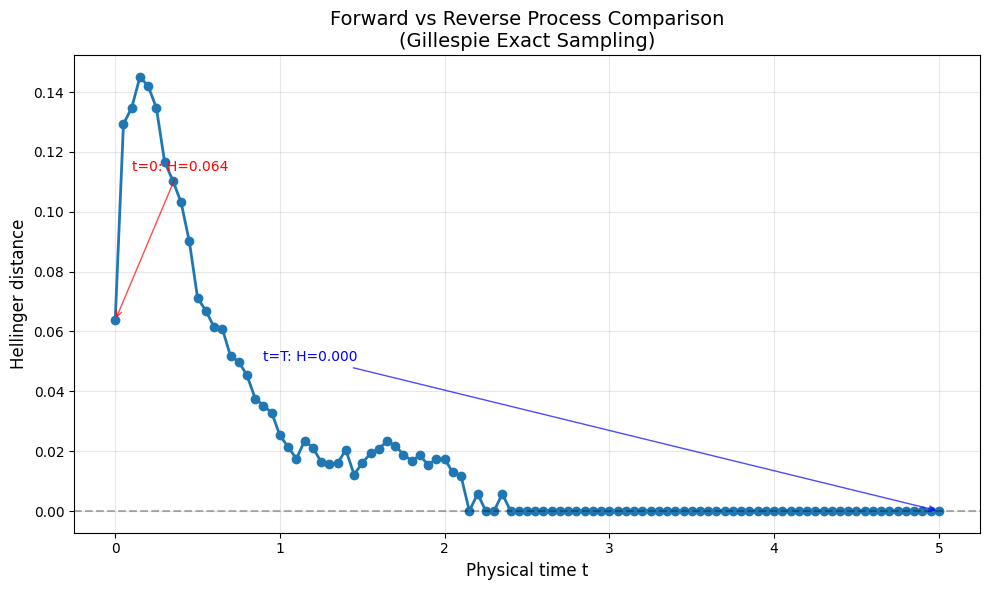


Experiment complete!

At t=0.25:
  Forward fraction masked: 70.9%
  Reverse fraction masked: 71.5%

At t=0.5:
  Forward fraction masked: 91.8%
  Reverse fraction masked: 91.8%

At t=0.75:
  Forward fraction masked: 97.6%
  Reverse fraction masked: 97.6%


In [6]:
# ============================================================================
# Main Script
# ============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("Gillespie Diffusion Experiment: Forward vs Reverse Comparison")
    print("=" * 70)
    
    # Setup parameters
    N = 5      # Number of dimensions
    L = 3      # Vocabulary size per dimension
    r = 10    # Number of mixture components
    w = np.ones(r) / r
    
    # w = np.array([0.3, 0.5, 0.2])  # Mixture weights
    mu = np.random.dirichlet([1]*L, size=(r, N))  # Shape: (r, N, L)
    
    beta = 5.0  # Masking rate
    T = 5.0     # Terminal time
    n_mc = 15_000 # Number of Monte Carlo samples
    
    # Checkpoint times (physical time from 0 to T)
    checkpoint_times = np.linspace(0, T, 101)  # [0.0, 0.05, ..., 1.0]
    
    print(f"\nParameters:")
    print(f"  N (dimensions) = {N}")
    print(f"  L (vocab size) = {L}")
    print(f"  r (components) = {r}")
    print(f"  beta (rate)    = {beta}")
    print(f"  T (term time)  = {T}")
    print(f"  n_mc (samples) = {n_mc}")
    print(f"  checkpoints    = {len(checkpoint_times)}")
    
    # Run experiment
    print("\n" + "=" * 70)
    samples = run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times)
    
    # Compute Hellinger distances
    print("\nComputing Hellinger distances...")
    distances = samples.compute_hellinger_distances()
    
    # Display results
    print("\nHellinger distances at checkpoints:")
    for t in samples.times[::4]:  # Print every 4th checkpoint
        if t in distances:
            print(f"  t = {t:.3f}: H = {distances[t]:.4f}")
    
    # Final distance
    t_final = samples.times[0]  # t=0 (should be best match)
    print(f"\n*** Final Hellinger distance at t={t_final}: {distances[t_final]:.4f} ***")
    
    # Plot results
    print("\nGenerating plot...")
    plt.figure(figsize=(10, 6))
    plt.plot(samples.times, [distances[t] for t in samples.times], 'o-', linewidth=2, markersize=6)
    plt.xlabel('Physical time t', fontsize=12)
    plt.ylabel('Hellinger distance', fontsize=12)
    plt.title('Forward vs Reverse Process Comparison\n(Gillespie Exact Sampling)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Annotate key points
    t0 = samples.times[0]
    tT = samples.times[-1]
    plt.annotate(f't=0: H={distances[t0]:.3f}', 
                xy=(t0, distances[t0]), xytext=(0.1, distances[t0] + 0.05),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                fontsize=10, color='red')
    plt.annotate(f't=T: H={distances[tT]:.3f}', 
                xy=(tT, distances[tT]), xytext=(0.9, distances[tT] + 0.05),
                arrowprops=dict(arrowstyle='->', color='blue', alpha=0.7),
                fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.savefig('gillespie_diffusion_results.png', dpi=150, bbox_inches='tight')
    print("Plot saved to: gillespie_diffusion_results.png")
    plt.show()
    
    print("\n" + "=" * 70)
    print("Experiment complete!")
    print("=" * 70)

    print(f"\nAt t=0.25:")
    t_q1 = 0.25
    if t_q1 in samples.forward:
        print(f"  Forward fraction masked: {(samples.forward[t_q1] == -1).sum() / samples.forward[t_q1].size:.1%}")
    if t_q1 in samples.reverse:
        print(f"  Reverse fraction masked: {(samples.reverse[t_q1] == -1).sum() / samples.reverse[t_q1].size:.1%}")
        

    print(f"\nAt t=0.5:")
    t_mid = 0.5
    if t_mid in samples.forward:
        print(f"  Forward fraction masked: {(samples.forward[t_mid] == -1).sum() / samples.forward[t_mid].size:.1%}")
    if t_mid in samples.reverse:
        print(f"  Reverse fraction masked: {(samples.reverse[t_mid] == -1).sum() / samples.reverse[t_mid].size:.1%}")
    print(f"\nAt t=0.75:")
    t_q3 = 0.75
    if t_q3 in samples.forward:
        print(f"  Forward fraction masked: {(samples.forward[t_q3] == -1).sum() / samples.forward[t_q3].size:.1%}")
    if t_q3 in samples.reverse:
        print(f"  Reverse fraction masked: {(samples.reverse[t_q3] == -1).sum() / samples.reverse[t_q3].size:.1%}")
        
    